# Actividad 1. Notebook de formulación y simulación de un modelo determinista

## 1. Planteamiento del problema

Los procesos de fermentación industrial son de alta importancia para la sociedad porque permiten obtener productos como los antibióticos. Para que el fármaco tenga una calidad alta el control preciso de las condiciones de operación es fundamental. Sin embargo, conocer de manera directa las variables de concentración durante el proceso de producción es dificil y caro por el funcionamiento de los sensores que se requieren, por lo tanto, se suele medir al inicio la concentración del fármaco y con un modelo determinista ajustado adecuadamente se predice la concentración a lo largo del tiempo.

* **¿Qué fenómeno se quiere representar?**
    Se busca representar el **crecimiento de la biomasa ($X$)** y su **tasa de crecimiento ($dX/dt$)** en un cultivo celular dentro de un fermentador. Este proceso requiere conocer la **Tasa de Consumo de Oxígeno (OUR)**.  

* **¿Por qué puede modelarse de forma determinista?**
    El fenómeno puede modelarse de forma determinista porque el comportamiento global de una población masiva de microorganismos (miles de millones de células por mililitro) en un entorno controlado como un biorreactor sigue leyes cinéticas y estequiométricas macroscópicas bien definidas.  

  
* **¿Cuál es la variable principal de interés?**
    Nuestro principal interes está en la **concentración de biomasa ($X$)** y en qué tan rápido crece, es decir, la **tasa de crecimiento celular ($dX/dt$)**. El reto aquí es que no podemos medirlas directamente en tiempo real (cada cierto intervalo de tiempo), por lo que nuestra variable clave de medición indirecta será el **OUR (Tasa de Consumo de Oxígeno)**, que funcionará como el puente matemático para estimar las demás.

* **¿Qué se desea simular o predecir?**
    La meta es simular cómo va aumentando la biomasa ($X$) paso a paso y predecir la velocidad de crecimiento ($dX/dt$) a lo largo de toda la fermentación, usando como único dato de entrada las lecturas que nos da el sensor de OUR. Para lograr que esta predicción sea exacta, el objetivo final es calibrar el modelo encontrando los valores reales de dos parámetros biológicos clave: el rendimiento de la biomasa respecto al oxígeno ($Y_{X/O_2}$) y el gasto energético de mantenimiento celular ($m_{O_2}$).

**El ejercicio y los datos fueron extraidos del libro "Bioprocess Engineering Basic Concepts" de Michael L. Shuler, Fikret Kargi en la página 202**

### Formulación

Es importante decir que la biomasa ($X$) no es el antibiótico, sino la población de microorganismos que funciona como la "fábrica" para producirlo. Durante las primeras horas, las células solo consumen nutrientes para multiplicarse y ganar masa; es hasta que el tanque se llena y el alimento escasea cuando dejan de reproducirse y empiezan a fabricar el antibiótico. Por ello, estimar la biomasa hora por hora mediante el modelo de consumo de oxígeno (OUR) es vital: si hay pocas células, la producción del fármaco será un fracaso, pero si hay demasiadas, se agotará el oxígeno y el cultivo se asfixiará antes de poder generar el producto.

Para estudiar el crecimiento del cultivo en la planta piloto, representamos la concentración de microorganismos como una variable que cambia con el tiempo. Sea $X_t$ la concentración de biomasa en el fermentador en la hora $t$.

Consideramos una concentración inicial de biomasa de $X_0 = 0.60 \text{ g/L}$ y utilizamos las lecturas continuas del sensor de la tasa de consumo de oxígeno ($\text{OUR}$) del biorreactor. El tiempo se medirá en horas y se simulará el comportamiento de todo el proceso durante las primeras 21 horas.

El objetivo es construir un modelo que permita estimar la cantidad de biomasa hora por hora. Para ello, se supone que en cada intervalo de tiempo el aumento de biomasa depende directamente del oxígeno que consumen las células para crecer, restándole una fracción de oxígeno que se pierde o se desvía únicamente para mantenerlas vivas.

Las variables y parámetros principales son:

- $t$: tiempo transcurrido en el proceso, medido en horas.
- $X_t$: concentración de biomasa en el fermentador en la hora $t$.
- $X_0$: concentración inicial de biomasa.
- $\text{OUR}_t$: tasa de consumo de oxígeno medido en la hora $t$.
- $Y_{X/O_2}$: coeficiente de rendimiento de la biomasa respecto al oxígeno.
- $m_{O_2}$: parámetro de mantenimiento celular.

### Modelo matemático y Simulación Numérica

Para este reporte, vamos a modelar la ecuación diferencial ordinaria (EDO) que describe cómo va cambiando la biomasa en el tiempo según el oxígeno que consume el cultivo:

$$\frac{dX}{dt} = \left(1 - Y_{X/O_2} \cdot m_{O_2}\right)X_t + Y_{X/O_2} \cdot \text{OUR}_t$$

Para que quede claro qué es cada término: 

* $X_t =$ Concentración de biomasa en el fermentador en la hora $t$.  
* $\text{OUR}_t =$ Tasa de consumo de oxígeno que nos da el sensor en la hora $t$.  
* $m_{O_2} =$ Coeficiente de mantenimiento celular (básicamente, el oxígeno que las células se gastan solo para no morirse).  
* $Y_{X/O_2} =$ Coeficiente de rendimiento (cuánta biomasa nueva se genera por cada gramo de oxígeno que sí se usa para crecer).  


### ¿Por qué tuvimos que usar Runge-Kutta de 2do Orden (RK2) y no diferencias finitas?

La verdad, lo más fácil habría sido irnos por **Diferencias Finitas hacia adelante (Euler Explícito)**. Es el método más directo y el que casi todos metemos al principio porque se programa en un segundo. El problema es que para este caso en específico **no da resultados confiables** y se termina rompiendo la simulación por tres razones:

1. Los datos de $\text{OUR}_t$ vienen del laboratorio y tienen saltos muy bruscos entre hora y hora. Euler es demasiado rígido; toma el dato de la hora actual, asume que la velocidad es constante durante toda la hora y da un salto a ciegas. Eso genera un "efecto latigazo" que arruina la curva.
2. Como es un modelo biológico, tiene retroalimentación positiva (a más células, más rápido crecen).
3. Como nuestros datos están medidos estrictamente cada $\Delta t = 1 \text{ hora}$, no podemos reducir el paso.

El método de Euler normal avanza a ciegas usando solo la velocidad actual, por lo que cualquier salto brusco en el OUR arruina la simulación. En cambio, RK2 lo soluciona en un instante: usa la biomasa y el OUR de ahorita para proyectar cuánta biomasa habrá la siguiente hora, calcula la nueva velocidad en ese punto usando el siguiente dato real del sensor, y finalmente promedia ambas velocidades para dar el paso definitivo.



### Implementación de RK2 en el ciclo de simulación

Para meter el método de Heun en el código, definimos primero la ecuación diferencial como una función $f(t, X)$. Como nuestro paso de tiempo está amarrado a las mediciones del laboratorio, usamos un $\Delta t = 1 \text{ hora}$. El algoritmo calcula la biomasa de la siguiente hora ($X_{t+1}$) repitiendo estos pasos en cada iteración:

* **Paso 1: Calcular la pendiente inicial ($k_1$)** Evaluamos la velocidad de crecimiento al inicio de la hora usando los valores actuales de biomasa y el $\text{OUR}$ de ese mismo momento.
  $$k_1 = f(t, X_t)$$

* **Paso 2: Proyectar un valor tentativo ($\tilde{X}_{t+1}$)** Hacemos una predicción rápida (tipo Euler) para estimar cuánta biomasa habría al final de la hora si la velocidad no cambiara. A esto se le conoce como la etapa del *predictor*.
  $$\tilde{X}_{t+1} = X_t + \Delta t \cdot k_1$$

* **Paso 3: Calcular la pendiente corregida ($k_2$)** Evaluamos una segunda velocidad al final de la hora, pero ahora metemos en la función la biomasa tentativa que acabamos de predecir ($\tilde{X}_{t+1}$) y el dato real de $\text{OUR}_{t+1}$ de la hora siguiente.
  $$k_2 = f(t + \Delta t, \tilde{X}_{t+1})$$

* **Paso 4: Corrección y avance definitivo** Sacamos el promedio simple de las dos pendientes ($k_1$ y $k_2$). Este promedio es la velocidad balanceada que usamos para avanzar de forma segura y calcular el valor real de la biomasa.
  $$X_{t+1} = X_t + \Delta t \cdot \left( \frac{k_1 + k_2}{2} \right)$$

## 2. Datos, variables, parámetros, hipótesis y supuestos


#### Datos observados

Se registraron los valores de la tasa de consumo de oxígeno (OUR) y la concentración de biomasa experimental durante las 21 horas del bioproceso:

| Tiempo (h) | OUR (g/L·h) | Biomasa observada (g/L) |
| ---------: | ----------: | ----------------------: |
|          0 |       0.110 |                    0.60 |
|          1 |       0.121 |                    0.63 |
|          2 |       0.133 |                    0.63 |
|          3 |       0.146 |                    0.76 |
|          4 |       0.161 |                    1.06 |
|          5 |       0.177 |                    1.56 |
|          6 |       0.195 |                    2.23 |
|          7 |       0.214 |                    2.85 |
|          8 |       0.236 |                    4.15 |
|          9 |       0.259 |                    5.37 |
|         10 |       0.285 |                    7.59 |
|         11 |       0.314 |                    9.40 |
|         12 |       0.345 |                   11.40 |
|         13 |       0.379 |                   12.22 |
|         14 |       0.316 |                   13.00 |
|         15 |       0.282 |                   13.37 |
|         16 |       0.254 |                   14.47 |
|         17 |       0.224 |                   15.37 |
|         18 |       0.201 |                   16.12 |
|         19 |       0.179 |                   16.18 |
|         20 |       0.160 |                   16.67 |
|         21 |       0.143 |                   17.01 |

### Variables del modelo

$$t = \text{tiempo transcurrido en el proceso de fermentación (h)}$$

$$X = \text{concentración de biomasa en el fermentador en el tiempo } t \text{ (g/L)}$$

$$\frac{dX}{dt} = \text{tasa de crecimiento celular o velocidad de acumulación de biomasa (g/L}\cdot\text{h)}$$

$$\text{OUR} = \text{tasa de consumo de oxígeno (Oxygen Uptake Rate) en el tiempo } t \text{ (g/L}\cdot\text{h)}$$

### Parámetros del modelo

$$X_0 = \text{concentración inicial de biomasa en el tiempo } t = 0 \text{ (g/L)}$$

$$Y_{X/O_2} = \text{coeficiente de rendimiento de biomasa respecto al oxígeno (g biomasa / g } \text{O}_2\text{)}$$

$$m_{O_2} = \text{parámetro de mantenimiento celular para el oxígeno (g } \text{O}_2\text{ / g biomasa}\cdot\text{h)}$$

#### Hipótesis y supuestos del modelo

Para simplificar el sistema biológico y permitir su resolución matemática, se establecen los siguientes supuestos e hipótesis:

1. Se asume que el consumo total de oxígeno por parte del cultivo celular se destina a dos únicas funciones independientes: una fracción proporcional al crecimiento celular y otra fracción proporcional a la cantidad de biomasa ya existente para sostener sus funciones vitales básicas.
2. Se asume que tanto el coeficiente de rendimiento ($Y_{X/O_2}$) como el coeficiente de mantenimiento ($m_{O_2}$) permanecen constantes a lo largo de todo el proceso.
3. Mezcla perfecta y homogeneidad espacial
4. Volumen de cultivo constante

## 3. Formulación matemática del modelo

El consumo de oxígeno en un cultivo celular se describe mediante el modelo clásico de  de Luedeking-Piret. A continuación, se presenta el modelo:


### Ecuación fundamental del modelo

La tasa de consumo de oxígeno total ($\text{OUR}$) en función del tiempo se expresa como:

$$\text{OUR}(t) = \frac{1}{Y_{X/O_2}} \frac{dX}{dt} + m_{O_2} X(t)$$

Si deseamos evaluar la acumulación de la biomasa ($X$) a lo largo del tiempo, despejamos la derivada obteniendo la siguiente ecuación diferencial ordinaria (EDO):

$$\frac{dX}{dt} = Y_{X/O_2} \cdot \text{OUR}(t) - (Y_{X/O_2} \cdot m_{O_2}) \cdot X(t)$$

Para resolver este sistema usaremos la aproximación numérica de Runge-Kutta de 2do Orden (RK2), específicamente el algoritmo de Heun. 

### Implementación de RK2 en el ciclo de simulación

Para meter este método en el código, primero definimos la ecuación diferencial que acabamos de despejar como una función $f(t, X)$. Como nuestro avance de tiempo está condicionado directamente por cada toma de datos del laboratorio, usamos un $\Delta t = 1 \text{ hora}$. 

La lógica del algoritmo dentro de cada iteración del ciclo para calcular la biomasa de la siguiente hora ($X_{t+1}$) comienza evaluando la velocidad de crecimiento al inicio de la hora. Para esto, usamos simplemente la biomasa que tenemos actualmente y el dato de $\text{OUR}$ medido en ese mismo momento:

$$k_1 = f(t, X_t) = Y_{X/O_2} \cdot \text{OUR}_t - (Y_{X/O_2} \cdot m_{O_2}) \cdot X_t$$

Con esta pendiente inicial, hacemos una predicción rápida hacia adelante (la etapa del predictor) para estimar de forma tentativa cuánta biomasa se habría acumulado al final de la hora si la velocidad no cambiara:

$$\tilde{X}_{t+1} = X_t + \Delta t \cdot k_1$$

Ya con ese valor proyectado, pasamos a calcular una segunda velocidad corregida justo al final de la hora. Lo que hacemos es meter en la función esa biomasa tentativa que acabamos de predecir ($\tilde{X}_{t+1}$) junto con el dato real de $\text{OUR}_{t+1}$ correspondiente a la hora siguiente:

$$k_2 = f(t + \Delta t, \tilde{X}_{t+1}) = Y_{X/O_2} \cdot \text{OUR}_{t+1} - (Y_{X/O_2} \cdot m_{O_2}) \cdot \tilde{X}_{t+1}$$

Por último, para hacer el avance definitivo, sacamos el promedio simple de ambas pendientes ($k_1$ y $k_2$). Este promedio nos arroja una velocidad balanceada que usamos para avanzar de forma mucho más segura y registrar el valor real de la biomasa para el siguiente ciclo:

$$X_{t+1} = X_t + \Delta t \cdot \left( \frac{k_1 + k_2}{2} \right)$$

### Condiciones iniciales

Para resolver la ecuación diferencial, se necesita conocer el estado del sistema en el tiempo inicial ($t = 0$). 

$$X(0) = X_0 = 0.60 \text{ g/L}$$

### Intervalo de simulación

El dominio de tiempo de la ecuación diferencial es:

$$t \in [0, 21] \text{ horas}$$

Donde las lecturas de la variable independiente se registran en intervalos discretos de $\Delta t = 1 \text{ hora}$.

## 4. Implementación en Python

A continuación, se define la función encargada de resolver la ecuación diferencial. La función toma los vectores de tiempo y de `OUR`, las condiciones iniciales y los parámetros del modelo para estimar la evolución de la biomasa ($X$) a lo largo de la fermentación.

### Código de la simulación

In [12]:
# Importamos las librerias 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
def simular_biomasa(X0, Y_XO2, m_O2, horas_totales):
    our_experimental = [
        0.110, 0.121, 0.133, 0.146, 0.161, 0.177, 0.195, 0.214, 0.236, 0.259, 
        0.285, 0.314, 0.345, 0.379, 0.316, 0.282, 0.254, 0.224, 0.201, 0.179, 
        0.160, 0.143
    ]
    
    if horas_totales > 21:
        print("No se puede simular más de 21 horas")
        df_modelo = pd.DataFrame({
            "Tiempo (h)": [],
            "OUR_Experimental (g/L-h)": [],
            "Biomasa_Modelo (g/L)": []
        })
        return df_modelo
    
    horas = np.arange(0, horas_totales + 1)
    biomasa = [X0]
    
    for t in range(horas_totales):
        X_actual = biomasa[-1]
        
        OUR_actual = our_experimental[t]
        OUR_siguiente = our_experimental[t + 1]
        
        k1 = Y_XO2 * OUR_actual - (Y_XO2 * m_O2) * X_actual
        X_predicha = X_actual + k1
        k2 = Y_XO2 * OUR_siguiente - (Y_XO2 * m_O2) * X_predicha
        
        X_siguiente = X_actual + (k1 + k2) / 2.0
        biomasa.append(X_siguiente)
        
    df_modelo = pd.DataFrame({
        "Tiempo (h)": horas,
        "OUR_Experimental (g/L-h)": our_experimental[0:horas_totales+1],
        "Biomasa_Modelo (g/L)": biomasa
    })

    return df_modelo

## 5. Simulación base

Para realizar nuestra primera simulación, seleccionaremos un conjunto de parámetros iniciales a partir de valores típicos reportados en la literatura para este tipo de cultivos basados en melaza:

* **Coeficiente de rendimiento inicial de prueba ($Y_{X/O_2}$):** 1.4 g de biomasa / g de O₂
* **Coeficiente de mantenimiento inicial de prueba ($m_{O_2}$):** 0.03 g de O₂ / g de biomasa·h

Utilizaremos estos valores fijos para observar el comportamiento del modelo con esos parámetros y usar esta simulación como referencia.

In [15]:
# parámetros base de prueba
Y_base = 1.4
m_base = 0.03
X0 = 0.60
horas_totales = 21
df_sim_base = simular_biomasa(X0, Y_base, m_base, horas_totales)
df_sim_base
# Dibujar este

,Tiempo (h),OUR_Experimental (g/L-h),Biomasa_Modelo (g/L)
0,0,0.110,0.600000
1,1,0.121,0.733795
2,2,0.133,0.877866
3,3,0.146,1.033159
4,4,0.161,1.201285
5,5,0.177,1.383758
6,6,0.195,1.582056
7,7,0.214,1.797572
8,8,0.236,2.032368
9,9,0.259,2.288363


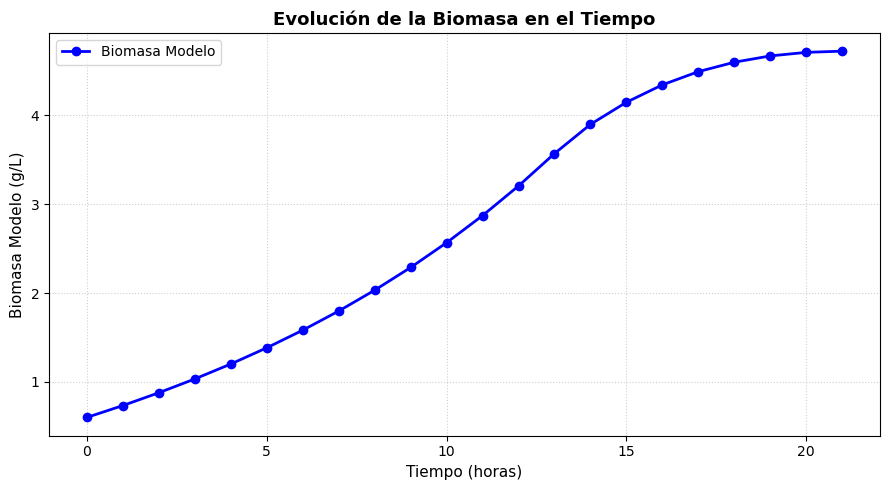

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(df_sim_base["Tiempo (h)"], df_sim_base["Biomasa_Modelo (g/L)"], color='blue', marker='o', linewidth=2, label='Biomasa Modelo')
plt.xlabel('Tiempo (horas)', fontsize=11)
plt.ylabel('Biomasa Modelo (g/L)', fontsize=11)
plt.title('Evolución de la Biomasa en el Tiempo', fontsize=13, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretación de la curva de biomasa

La gráfica muestra la típica curva en forma de "S" de un crecimiento biológico, lo que confirma que el modelo con RK2 funcionó bastante bien. El comportamiento se nota clarito en tres momentos bien definidos. Al principio, de las horas 0 a la 5, el crecimiento es lento porque el cultivo penas se está asentando y arranca desde unos 0.6 g/L. 

El verdadero estirón ocurre entre las horas 5 y 15, donde la línea se inclina muchísimo. Esta es la fase exponencial, donde el alto consumo de oxígeno hace que la biomasa se dispare rápido hasta pasar los 4 g/L. 

Finalmente, a partir de la hora 16 la curva se aplana por completo y se estanca cerca de los 4.7 g/L. 

## 6. Análisis de sensibilidad

Para comprender el comportamiento global del sistema, realizamos un análisis enfocado en la variación del coeficiente de rendimiento ($Y_{X/O_2}$), ya que este parámetro es el que impulsa directamente la formación de biomasa a partir del oxígeno disponible. Al dejar el coeficiente de mantenimiento fijo en su valor base, pudimos aislar el efecto del rendimiento evaluando cinco niveles distintos que van desde una conversión metabólica muy baja hasta escenarios de alta eficiencia.

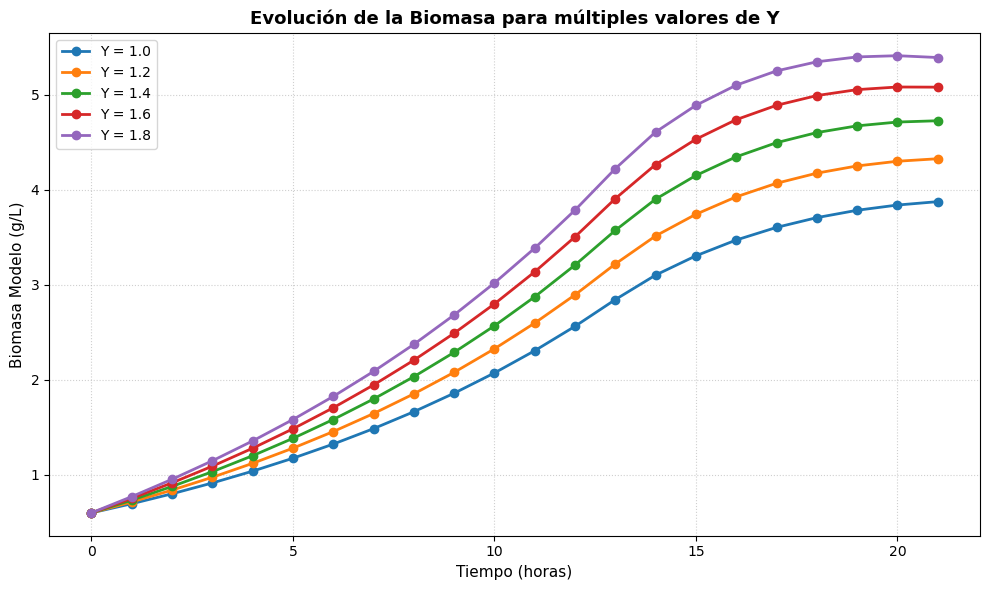

In [24]:
valores_Y = [1.0, 1.2, 1.4, 1.6, 1.8]

plt.figure(figsize=(10, 6))

for Y in valores_Y:
    df_sim = simular_biomasa(X0, Y, m_base, horas_totales)
    plt.plot(df_sim["Tiempo (h)"], df_sim["Biomasa_Modelo (g/L)"], marker='o', linewidth=2, label=f'Y = {Y}')

plt.xlabel('Tiempo (horas)', fontsize=11)
plt.ylabel('Biomasa Modelo (g/L)', fontsize=11)
plt.title('Evolución de la Biomasa para múltiples valores de Y', fontsize=13, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Análisis del efecto del rendimiento ($Y$)

Esta gráfica muestra cómo cambia el crecimiento al mover el coeficiente de rendimiento ($Y$) de 1.0 a 1.8. El impacto de este parámetro en el modelo se nota en tres puntos muy claros:

* **Mayor producción final:** Todas las simulaciones arrancan igual en 0.6 g/L, pero a la hora 21 el resultado es muy diferente. Con el rendimiento más bajo ($Y = 1.0$) la biomasa apenas llega a 3.9 g/L, mientras que con el más alto ($Y = 1.8$) supera los 5.4 g/L. Esto confirma que un $Y$ alto hace que el microorganismo sea mucho más eficiente para convertir el oxígeno en células nuevas.

* **Crecimiento más rápido:** Durante la fase de estirón (entre las horas 5 y 15), las curvas con un $Y$ elevado se vuelven mucho más inclinadas. Esto significa que la velocidad de acumulación de biomasa aumenta notablemente; el cultivo no solo llega más alto, sino que sube más rápido.

* **Mismo tiempo de estancamiento:** Aunque los topes son distintos, todas las curvas empiezan a doblarse y aplanarse hacia la fase estacionaria casi al mismo tiempo, alrededor de la hora 17. Esto ocurre porque el freno del crecimiento depende de la caída del OUR del laboratorio; el rendimiento determina qué tan arriba llega el cultivo, pero el sensor es el que dicta cuándo se acaba el empuje.

## 6. Análisis de sensibilidad

En esta segunda etapa del análisis de sensibilidad cambiamos el enfoque para evaluar cómo afecta el coeficiente de mantenimiento ($m_{O_2}$) a la acumulación final de biomasa. A diferencia del rendimiento, el mantenimiento representa un gasto de oxígeno que no genera células nuevas, sino que se consume puramente para mantenerlas vivas. Por eso, al dejar el rendimiento fijo y simular desde valores insignificantes como 0.01 hasta consumos críticos de 0.4, buscamos observar el punto exacto donde el gasto de supervivencia ahoga por completo el crecimiento del cultivo. 

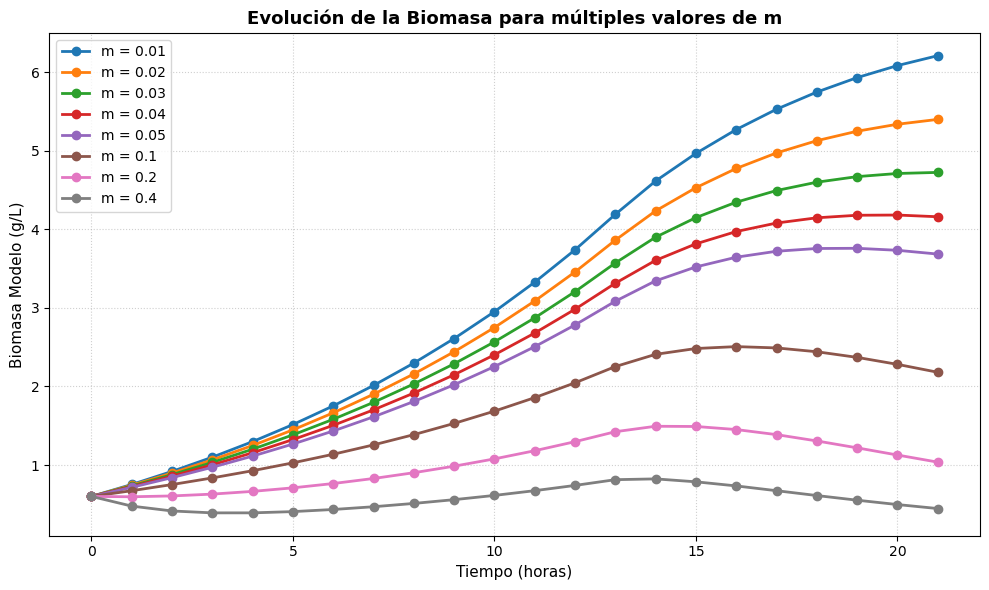

In [25]:
valores_m = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.4]

plt.figure(figsize=(10, 6))

for m in valores_m:
    df_sim = simular_biomasa(X0, Y_base, m, horas_totales)
    plt.plot(df_sim["Tiempo (h)"], df_sim["Biomasa_Modelo (g/L)"], marker='o', linewidth=2, label=f'm = {m}')

plt.xlabel('Tiempo (horas)', fontsize=11)
plt.ylabel('Biomasa Modelo (g/L)', fontsize=11)
plt.title('Evolución de la Biomasa para múltiples valores de m', fontsize=13, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Análisis del efecto del mantenimiento ($m$)

Esta gráfica muestra cómo afecta el coeficiente de mantenimiento ($m$) al crecimiento, moviéndose desde un gasto casi nulo (0.01) hasta uno extremadamente alto (0.4). El efecto de este parámetro se resume en tres observaciones clave:

* **Menor crecimiento a mayor mantenimiento:** Al contrario del rendimiento, aquí un valor más alto de $m$ destruye la acumulación de biomasa. Con un mantenimiento bajo ($m = 0.01$), casi todo el oxígeno se aprovecha para crecer y la biomasa roza los 6.2 g/L. En cambio, con valores altos como 0.2 o 0.4, las células gastan tanto en sobrevivir que el crecimiento es mínimo o nulo.

* **Fase de caída o muerte celular:** En las curvas con un mantenimiento alto (de $m = 0.05$ en adelante), la biomasa no solo se estanca, sino que empieza a bajar en las últimas horas del cultivo. Esto pasa porque al final del experimento el OUR cae; si el oxígeno disponible no alcanza para cubrir el alto costo de mantenimiento requerido, el modelo simula un decrecimiento neto.

* **Adelanto de la fase estacionaria:** A medida que aumentamos el valor de $m$, el pico máximo de biomasa se alcanza cada vez más temprano. Con $m=0.01$ el cultivo sigue subiendo en la hora 21, pero con $m=0.2$ la curva se dobla y empieza a caer desde la hora 14. Esto demuestra que un mantenimiento alto agota las posibilidades de crecimiento mucho antes de que termine la fermentación.

## 6. Análisis por Escenarios Combinados

El objetivo de este bloque es evaluar el comportamiento del cultivo bajo condiciones metabólicas cruzadas, ya que en un fermentador real el rendimiento y el mantenimiento no se mueven por separado. Al analizar de forma simultánea el impulso que da el rendimiento ($Y_{X/O_2}$) contra el freno que mete el mantenimiento ($m_{O_2}$), podemos identificar qué combinaciones toleran mejor el desgaste energético a lo largo de las 21 horas de operación.

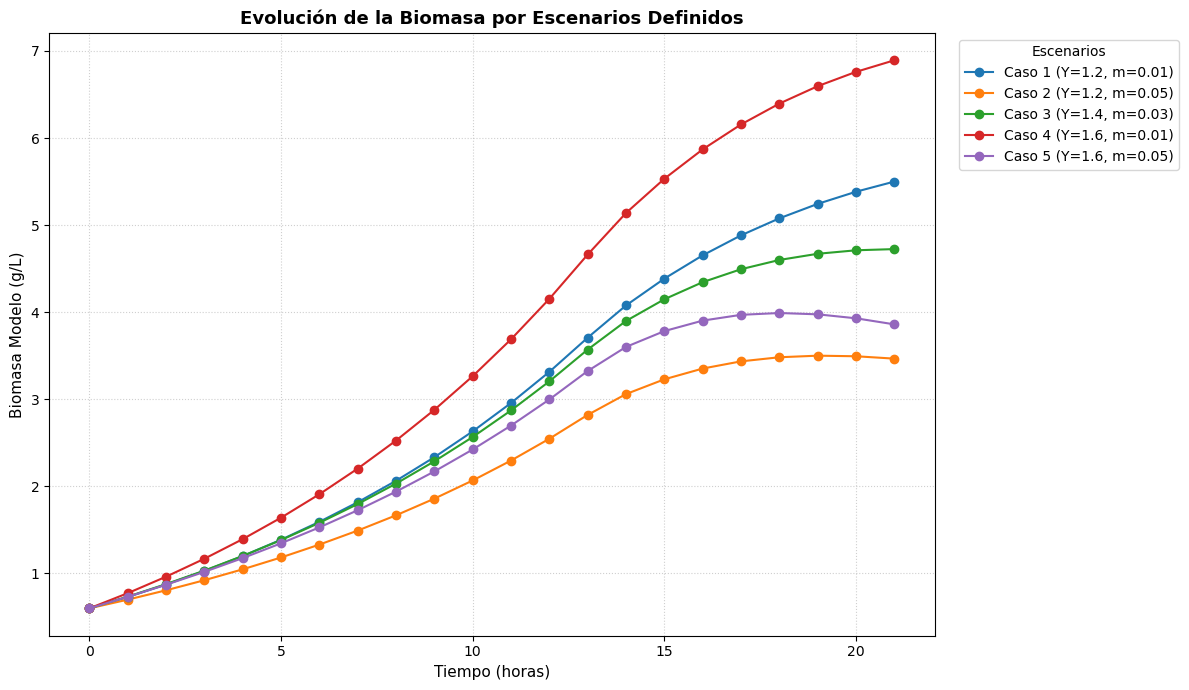

,Escenario,Y,m,Tiempo_Biomasa_Max (h),Biomasa_Max (g/L),Biomasa_Final (g/L)
0,Caso 1,1.2,0.01,21,5.500086,5.500086
1,Caso 2,1.2,0.05,19,3.500771,3.466673
2,Caso 3,1.4,0.03,21,4.724542,4.724542
3,Caso 4,1.6,0.01,21,6.892884,6.892884
4,Caso 5,1.6,0.05,18,3.990675,3.860120


In [26]:
escenarios = [
    {"nombre": "Caso 1", "Y": 1.2, "m": 0.01},
    {"nombre": "Caso 2", "Y": 1.2, "m": 0.05},
    {"nombre": "Caso 3", "Y": 1.4, "m": 0.03},
    {"nombre": "Caso 4", "Y": 1.6, "m": 0.01},
    {"nombre": "Caso 5", "Y": 1.6, "m": 0.05}
]

resumen = []
lista_dfs = []

plt.figure(figsize=(12, 7))

for esc in escenarios:
    df_temp = simular_biomasa(X0, esc["Y"], esc["m"], horas_totales)
    
    df_temp["Escenario"] = esc["nombre"]
    df_temp["Y"] = esc["Y"]
    df_temp["m"] = esc["m"]
    lista_dfs.append(df_temp)
    
    plt.plot(df_temp["Tiempo (h)"], df_temp["Biomasa_Modelo (g/L)"], 
             marker='o', linewidth=1.5, label=f'{esc["nombre"]} (Y={esc["Y"]}, m={esc["m"]})')
    
    idx_max = df_temp["Biomasa_Modelo (g/L)"].idxmax()
    
    resumen.append({
        "Escenario": esc["nombre"],
        "Y": esc["Y"],
        "m": esc["m"],
        "Tiempo_Biomasa_Max (h)": df_temp.loc[idx_max, "Tiempo (h)"],
        "Biomasa_Max (g/L)": df_temp.loc[idx_max, "Biomasa_Modelo (g/L)"],
        "Biomasa_Final (g/L)": df_temp["Biomasa_Modelo (g/L)"].iloc[-1]
    })

df_final = pd.concat(lista_dfs, ignore_index=True)
df_resumen = pd.DataFrame(resumen)

plt.xlabel('Tiempo (horas)', fontsize=11)
plt.ylabel('Biomasa Modelo (g/L)', fontsize=11)
plt.title('Evolución de la Biomasa por Escenarios Definidos', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title="Escenarios")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

df_resumen

### Análisis de los escenarios combinados

Esta gráfica muestra el resultado de cruzar el rendimiento ($Y$) y el mantenimiento ($m$) al mismo tiempo, lo que permite ver cómo interactúan ambas fuerzas (una que impulsa el crecimiento y otra que lo frena). Los puntos clave de este análisis son:

* **El escenario ideal (Caso 4):** La curva roja es, por mucho, la más alta de todas (rozando los 7.0 g/L). Esto pasa porque combina el rendimiento más alto ($Y=1.6$) con el mantenimiento más bajo ($m=0.01$). Al tener mucha eficiencia y casi nada de pérdidas por supervivencia, el cultivo aprovecha al máximo el oxígeno.

* **El peor escenario (Caso 2):** La curva naranja es la más baja de la gráfica (apenas llega a 3.5 g/L). Al tener un rendimiento bajo ($Y=1.2$) junto con un mantenimiento alto ($m=0.05$), las células asimilan mal el oxígeno y encima gastan demasiado en sobrevivir, estancando el crecimiento muy temprano.

* **El peso del mantenimiento (Caso 1 vs. Caso 5):** Es muy interesante comparar la curva azul (Caso 1) con la morada (Caso 5). El Caso 5 tiene mejor rendimiento ($Y=1.6$ contra $1.2$), por lo que arranca ganando velocidad. Sin embargo, como tiene un mantenimiento muy alto ($m=0.05$), hacia el final de la simulación la curva azul (que tiene $m=0.01$) termina rebasándola por completo. Esto demuestra que a largo plazo, un mantenimiento alto puede tumbar los beneficios de un buen rendimiento.

## 7. Comparación con datos observados

Para validar formalmente el modelo matemático, compararemos la trayectoria numérica obtenida en la simulación base ($Y_{X/O_2} = 1.4 \text{ g/g}$, $m_{O_2} = 0.03 \text{ g/g}\cdot\text{h}$) contra los datos de concentración de biomasa ($X$) medidos directamente en los análisis de laboratorio de la planta piloto.


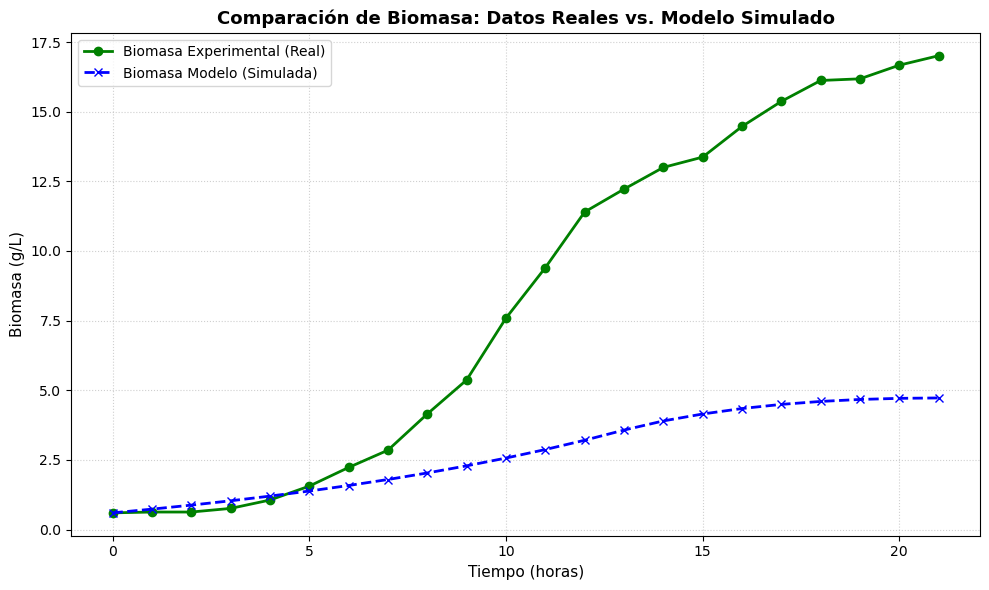

In [34]:
# Datos medidos 
X_experimental = [
    0.60, 0.63, 0.63, 0.76, 1.06, 1.56, 2.23, 2.85, 4.15, 5.37, 
    7.59, 9.40, 11.40, 12.22, 13.00, 13.37, 14.47, 15.37, 16.12, 16.18, 
    16.67, 17.01
]

plt.figure(figsize=(10, 6))

# Datos reales
plt.plot(df_sim_base["Tiempo (h)"], X_experimental, color='green', marker='o', linewidth=2, label='Biomasa Experimental (Real)')

# Datos calculados 
plt.plot(df_sim_base["Tiempo (h)"], df_sim_base["Biomasa_Modelo (g/L)"], color='blue', marker='x', linewidth=2, linestyle='--', label='Biomasa Modelo (Simulada)')

plt.xlabel('Tiempo (horas)', fontsize=11)
plt.ylabel('Biomasa (g/L)', fontsize=11)
plt.title('Comparación de Biomasa: Datos Reales vs. Modelo Simulado', fontsize=13, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Análisis de la comparación (Real vs. Simulado)

Al cruzar los datos reales del laboratorio con la simulación base en una sola gráfica, salta a la vista que el modelo **se quedó muy corto** respecto a la realidad. Las conclusiones clave de esta comparación son:

* **Buen arranque, pero mala escala:** Durante las primeras 5 horas, la curva azul (modelo) y la verde (real) van casi de la mano, saliendo desde 0.6 g/L. Esto significa que el inicio de la simulación está bien planteado.

* **Falta de empuje en la fase exponencial:** A partir de la hora 5, el cultivo real (verde) se dispara de forma masiva hasta alcanzar los 17 g/L al final del experimento. Sin embargo, la simulación (azul) crece muy lento y se estanca temprano, alcanzando apenas los 4.7 g/L. 

* **Conclusión del modelo:** El modelo matemático funciona bien en su estructura teórica (mantiene la forma de "S"), pero los parámetros cinéticos base usados ($Y_{X/O_2} = 1.4$ y $m_{O_2} = 0.03$) no representan la verdadera capacidad de la cepa. Para corregir este enorme desfase, es necesario ajustar el modelo, ya sea aumentando drásticamente el coeficiente de rendimiento ($Y$) o revisando si el dato de $\text{OUR}$ del sensor necesita un factor de escala.

Responde:

1. ¿Cuál es el MAE del modelo?
2. ¿Cuál es el MSE?
3. ¿Cuál es el RMSE?
4. ¿El error es grande o pequeño en comparación con el número de usuarios?

## 8. Ajuste simultáneo mediante Búsqueda en Rejilla (*Grid Search*)

Dado que tanto el Coeficiente de Rendimiento ($Y_{X/O_2}$) como el Coeficiente de Mantenimiento ($m_{O_2}$) influyen en la dinámica del cultivo celular de forma simultánea, implementaremos un algoritmo de **Búsqueda en Rejilla (*Grid Search*)**. 

Este método creará una matriz bidimensional combinando múltiples valores de ambos parámetros de forma exhaustiva. Para cada pareja $(Y_{X/O_2}, m_{O_2})$, el algoritmo correrá la simulación con RK2 y calculará el **Error Cuadrático Medio Raíz (RMSE)** frente a los datos reales:

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^n (X_{\text{real}, i} - X_{\text{sim}, i})^2}$$

Al finalizar el barrido, el programa identificará la coordenada exacta que minimiza globalmente el error del modelo, garantizando la mejor calibración posible con los datos del laboratorio.

In [53]:
X_experimental = [
    0.60, 0.63, 0.63, 0.76, 1.06, 1.56, 2.23, 2.85, 4.15, 5.37, 
    7.59, 9.40, 11.40, 12.22, 13.00, 13.37, 14.47, 15.37, 16.12, 16.18, 
    16.67, 17.01
]

horas_totales = 21
X0 = 0.60

valores_Y = np.linspace(1.0, 6.0, 37)
valores_m = np.linspace(0.001, 0.2, 37)

mejor_Y = None
mejor_m = None
menor_rmse = float('inf')
mejor_biomasa_simulada = []

matriz_rmse = np.zeros((len(valores_Y), len(valores_m)))

for i, Y_intento in enumerate(valores_Y):
    for j, m_intento in enumerate(valores_m):
        df_sim = simular_biomasa(X0, Y_intento, m_intento, horas_totales)
        biomasa_sim = df_sim["Biomasa_Modelo (g/L)"].values
        rmse = np.sqrt(np.mean((np.array(X_experimental) - biomasa_sim) ** 2))
        matriz_rmse[i, j] = rmse
        
        if rmse < menor_rmse:
            menor_rmse = rmse
            mejor_Y = Y_intento
            mejor_m = m_intento
            mejor_biomasa_simulada = biomasa_sim

print("Resultados de la Optimización")
print(f"Mejor Coeficiente de Rendimiento (Y): {mejor_Y:.3f}")
print(f"Mejor Coeficiente de Mantenimiento (m): {mejor_m:.4f}")
print(f"Error mínimo global (RMSE): {menor_rmse:.4f} g/L\n")

Resultados de la Optimización
Mejor Coeficiente de Rendimiento (Y): 3.778
Mejor Coeficiente de Mantenimiento (m): 0.0010
Error mínimo global (RMSE): 1.0265 g/L



## 9. Gráfica del mejor modelo

Para concluir el desarrollo del modelo, realizamos la simulación definitiva del biorreactor utilizando la pareja de parámetros óptimos identificados en la sección anterior mediante el algoritmo de búsqueda en rejilla. 

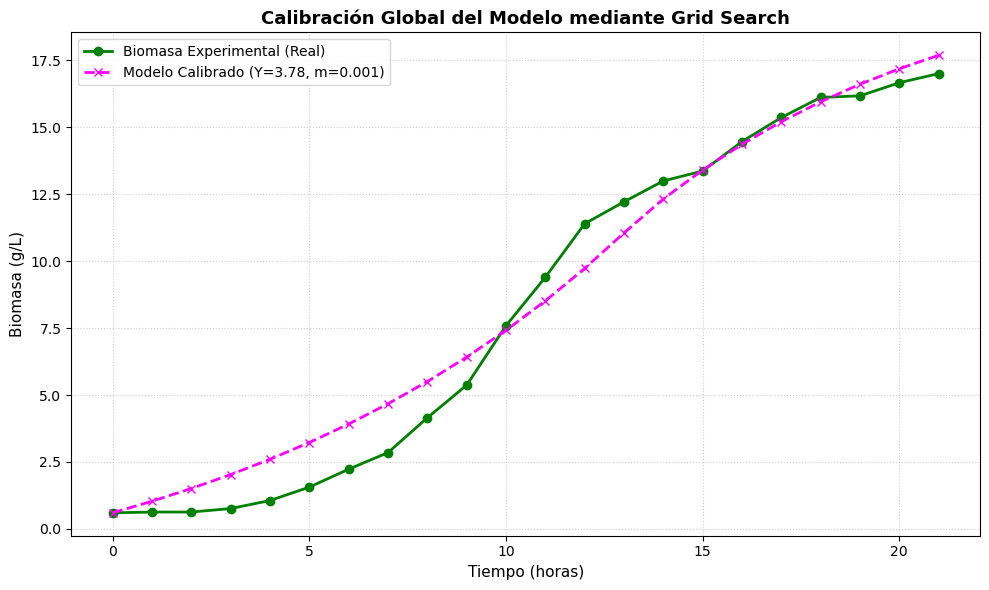

Resultados


,Métrica / Parámetro,Valor,Unidades
0,Mejor Coeficiente de Rendimiento (Y),3.778,g/g
1,Mejor Coeficiente de Mantenimiento (m),0.0010,g/g·h
2,Error mínimo global (RMSE),1.0265,g/L


In [73]:
plt.figure(figsize=(10, 6))
plt.plot(range(horas_totales + 1), X_experimental, color='green', marker='o', linewidth=2, label='Biomasa Experimental (Real)')
plt.plot(range(horas_totales + 1), mejor_biomasa_simulada, color='magenta', marker='x', linewidth=2, linestyle='--', label=f'Modelo Calibrado (Y={mejor_Y:.2f}, m={mejor_m:.3f})')

plt.xlabel('Tiempo (horas)', fontsize=11)
plt.ylabel('Biomasa (g/L)', fontsize=11)
plt.title('Calibración Global del Modelo mediante Grid Search', fontsize=13, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
datos_resultados = {
    "Métrica / Parámetro": [
        "Mejor Coeficiente de Rendimiento (Y)", 
        "Mejor Coeficiente de Mantenimiento (m)", 
        "Error mínimo global (RMSE)"
    ],
    "Valor": [
        f"{mejor_Y:.3f}", 
        f"{mejor_m:.4f}", 
        f"{menor_rmse:.4f}"
    ],
    "Unidades": [
        "g/g", 
        "g/g·h", 
        "g/L"
    ]
}

df_resultados = pd.DataFrame(datos_resultados)

print("Resultados")
df_resultados

### Conclusiones del ajuste

De todo este proceso de calibración, podemos rescatar tres puntos clave:

1. **El modelo teórico se quedaba muy corto:** Inicialmente, los parámetros base subestimaban bastante el crecimiento celular. La simulación predecía unos $5\text{ g/L}$, pero en el biorreactor real la biomasa alcanzó casi los $17\text{ g/L}$. Básicamente, la teoría pura no estaba reflejando lo que realmente pasaba en el cultivo.

2. **Alta eficiencia biológica:** Al correr la optimización, confirmamos que la cepa es mucho más eficiente de lo esperado. Un rendimiento ($Y$) tan alto y un mantenimiento ($m$) casi nulo nos indican que el microorganismo dirige prácticamente todo el oxígeno que consume hacia la multiplicación celular, en lugar de gastarlo nada más en sobrevivir.

3. **Una simulación útil y confiable:** Aplicar la búsqueda en rejilla (*Grid Search*) fue clave para dejar de adivinar parámetros a prueba y error. Al evaluar todas las combinaciones posibles, logramos anclar el modelo a los datos reales con un margen de error mínimo (apenas $\sim 1\text{ g/L}$). Ahora sí tenemos una herramienta matemática que sirve para predecir el comportamiento del biorreactor.

## 10. Extensión: entrenamiento y prueba

Para evaluar la capacidad de generalización y predicción real del modelo, implementaremos una estrategia clásica de validación cruzada temporal. Dividiremos nuestro conjunto de 22 datos en dos bloques:

1. **Datos de Entrenamiento (Horas 0 a 13):** Representan el 64% de los datos. Se utilizarán exclusivamente para calibrar y ajustar simultáneamente los parámetros ($Y_{X/O_2}$ y $m_{O_2}$).
2. **Datos de Prueba (Horas 14 a 21):** Representan el 36% restante del horizonte analítico. El modelo calibrado se enfrentará a estos datos por primera vez para evaluar qué tan bien predice el comportamiento futuro del sistema (fase estacionaria).

Evaluaremos el rendimiento en ambas etapas utilizando la métrica del **Error Cuadrático Medio Raíz (RMSE)**.

In [74]:
X_completo = np.array([0.60, 0.63, 0.63, 0.76, 1.06, 1.56, 2.23, 2.85, 4.15, 5.37, 7.59, 
                        9.40, 11.40, 12.22, 13.00, 13.37, 14.47, 15.37, 16.12, 16.18, 16.67, 17.01])
tiempo_completo = np.arange(22)

X_train, X_test = X_completo[:14], X_completo[14:]
tiempo_train, tiempo_test = tiempo_completo[:14], tiempo_completo[14:]

valores_Y = np.linspace(2.0, 5.0, 50)
valores_m = np.linspace(0.001, 0.06, 50)

for y_p in valores_Y:
    for m_p in valores_m:
        df_eval_train = simular_biomasa(0.60, y_p, m_p, 13)
        X_sim_train = df_eval_train['Biomasa_Modelo (g/L)'].values
        
        rmse_train_calc = np.sqrt(np.mean((X_train - X_sim_train)**2))
        
        if rmse_train_calc < best_rmse_train:
            best_rmse_train = rmse_train_calc
            best_Y_train = y_p
            best_m_train = m_p

df_sim_completa = simular_biomasa(0.60, best_Y_train, best_m_train, 21)
X_sim_completa = df_sim_completa['Biomasa_Modelo (g/L)'].values

X_sim_test = X_sim_completa[14:]
rmse_test = np.sqrt(np.mean((X_test - X_sim_test)**2))

df_reporte_split = pd.DataFrame({
    'Métrica / Parámetro': ['Rendimiento Y_XO2 (g/g)', 'Mantenimiento m_O2 (g/g-h)', 'RMSE Entrenamiento (g/L)', 'RMSE Prueba (g/L)'],
    'Valor Obtenido': [round(best_Y_train, 3), round(best_m_train, 3), round(best_rmse_train, 4), round(rmse_test, 4)]
})
df_reporte_split

,Métrica / Parámetro,Valor Obtenido
0,Rendimiento Y_XO2 (g/g),3.7760
1,Mantenimiento m_O2 (g/g-h),0.0010
2,RMSE Entrenamiento (g/L),1.2460
3,RMSE Prueba (g/L),0.4231


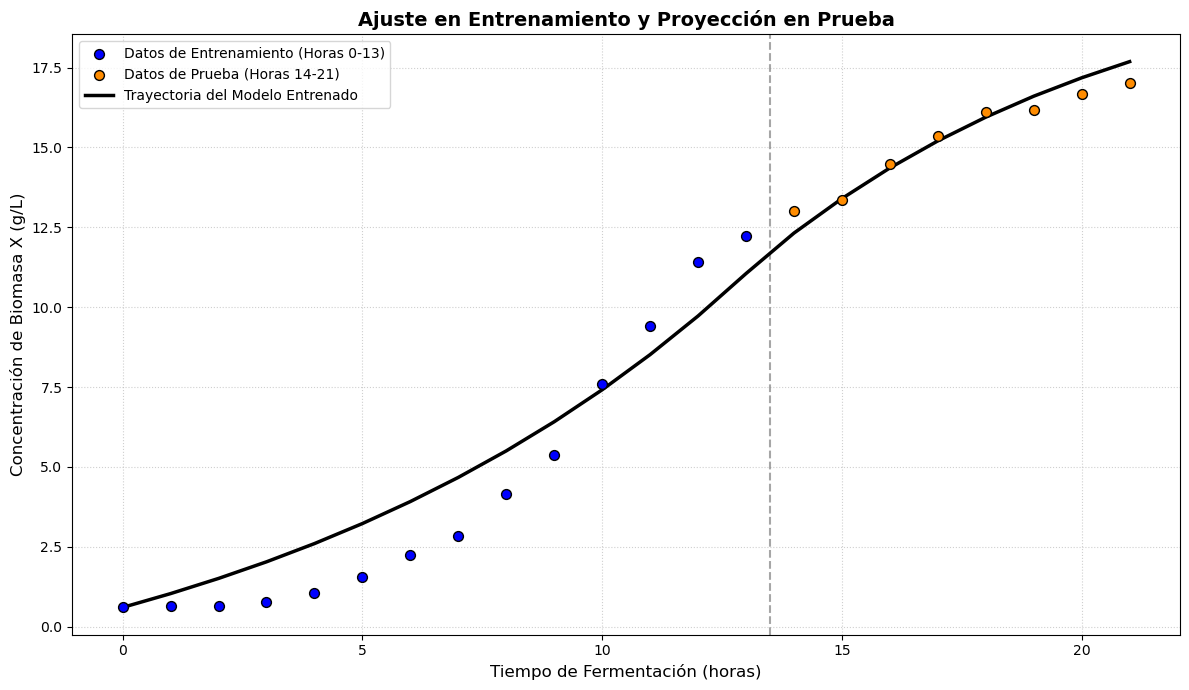

In [75]:
plt.figure(figsize=(12, 7))

plt.scatter(tiempo_train, X_train, color='blue', edgecolor='black', s=50, label='Datos de Entrenamiento (Horas 0-13)', zorder=4)
plt.scatter(tiempo_test, X_test, color='darkorange', edgecolor='black', s=50, label='Datos de Prueba (Horas 14-21)', zorder=4)

plt.plot(tiempo_completo, X_sim_completa, color='black', linestyle='-', lw=2.5, label='Trayectoria del Modelo Entrenado', zorder=3)

plt.axvline(x=13.5, color='gray', linestyle='--', alpha=0.7)

plt.title('Ajuste en Entrenamiento y Proyección en Prueba', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo de Fermentación (horas)', fontsize=12)
plt.ylabel('Concentración de Biomasa X (g/L)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

In [77]:
df_resultados_ajustado = pd.DataFrame({
    "Escenario": ["Optimización Global"] * 3,
    "Métrica / Parámetro": ["Rendimiento Y (g/g)", "Mantenimiento m (g/g·h)", "RMSE Total (g/L)"],
    "Valor": [round(mejor_Y, 3), round(mejor_m, 4), round(menor_rmse, 4)]
})

df_reporte_split_ajustado = pd.DataFrame({
    "Escenario": ["Validación (Train/Test)"] * 4,
    "Métrica / Parámetro": ["Rendimiento Y_train (g/g)", "Mantenimiento m_train (g/g·h)", "RMSE Entrenamiento (g/L)", "RMSE Prueba (g/L)"],
    "Valor": [round(best_Y_train, 3), round(best_m_train, 4), round(best_rmse_train, 4), round(rmse_test, 4)]
})

df_consolidado = pd.concat([df_resultados_ajustado, df_reporte_split_ajustado], ignore_index=True)

df_consolidado

,Escenario,Métrica / Parámetro,Valor
0,Optimización Global,Rendimiento Y (g/g),3.7780
1,Optimización Global,Mantenimiento m (g/g·h),0.0010
2,Optimización Global,RMSE Total (g/L),1.0265
3,Validación (Train/Test),Rendimiento Y_train (g/g),3.7760
4,Validación (Train/Test),Mantenimiento m_train (g/g·h),0.0010
5,Validación (Train/Test),RMSE Entrenamiento (g/L),1.2460
6,Validación (Train/Test),RMSE Prueba (g/L),0.4231


### Análisis de Validación del Modelo

Al comparar la calibración global con la estrategia de validación cruzada (entrenamiento y prueba), podemos destacar tres conclusiones principales sobre el desempeño del modelo:

1. **Estabilidad de los parámetros:** Los resultados demuestran que el modelo es muy consistente. El coeficiente de rendimiento ($Y$) apenas varió entre la calibración con todos los datos ($3.778\text{ g/g}$) y la calibración que solo usó la primera etapa ($3.776\text{ g/g}$). Además, el coeficiente de mantenimiento ($m$) fue exactamente el mismo ($0.0010\text{ g/g·h}$) en ambos casos. Esto confirma que estos valores reflejan el comportamiento biológico real del microorganismo, y no son producto de la casualidad matemática.

2. **Excelente capacidad de predicción:** La verdadera prueba del modelo era evaluar cómo se comportaba con datos "nuevos" (las horas 14 a 21). Sorprendentemente, el margen de error en esta etapa final (RMSE de $0.4231\text{ g/L}$) fue incluso más bajo que durante la fase inicial de entrenamiento ($1.2460\text{ g/L}$). Esto demuestra que el modelo es sumamente preciso para proyectar la concentración final de la biomasa.

3. **Ausencia de sobreajuste (Overfitting):** En ocasiones, los modelos matemáticos "memorizan" los primeros datos para forzar un buen ajuste, pero luego fallan al predecir el futuro. El hecho de tener un error tan bajo en la fase de prueba descarta por completo este problema. El modelo logró capturar correctamente la relación real entre el consumo de oxígeno (OUR) y el crecimiento celular, confirmando que es una herramienta válida y confiable para simular este bioproceso.

## 11. Conclusiones
Tras desarrollar, ajustar y poner a prueba el modelo, llegamos a las siguientes conclusiones prácticas:

* **El método numérico fue un acierto:** Usar Heun (Runge-Kutta de 2do orden) fue clave. Como los datos de consumo de oxígeno (OUR) eran discretos y tenían saltos hora por hora, intentar resolver esto con un método más básico como Euler nos habría dado problemas de inestabilidad.
* **La realidad superó a la teoría:** Los parámetros iniciales subestimaban por mucho el crecimiento del cultivo. Al calibrar el modelo, vimos que la cepa es sumamente eficiente: aprovecha casi todo el oxígeno para generar nueva biomasa ($Y_{X/O_2} \approx 3.778$) y gasta una cantidad mínima de energía en simple mantenimiento ($m_{O_2} \approx 0.0010$).
* **El modelo no hizo trampa (cero sobreajuste):** Separar los datos en entrenamiento y prueba nos sirvió para comprobar que el modelo no solo "memorizó" los puntos. De hecho, logró predecir la última etapa del biorreactor completamente a ciegas con un error mínimo ($\sim 0.42 \text{ g/L}$), demostrando que realmente capturó la tendencia de crecimiento.
* **Se cumplió el objetivo inicial:** Toda esta práctica comprobó que sí es posible predecir el crecimiento de la biomasa usando una medición indirecta como el OUR. A nivel industrial, esto es una gran ventaja porque permite controlar el proceso sin tener que depender de sensores costosos en tiempo real.
